In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###Load data

In [ ]:
df = pd.read_csv("/content/zomato_raw_datasets.csv")

In [ ]:
df.head()

,name,url,rating,location,city,area,cuisine,price,reviews,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,is_delivering_now,switch_to_order_menu
0,85°C Bakery Cafe,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Cafe,Low,1609,Cafe,1992,Yes,No,349.0,No,Yes
1,Applebee's,https://en.wikipedia.org/wiki/List_of_restaura...,4.7,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,1424,Casual Dining,2702,No,No,566.0,No,No
2,Arby's,https://en.wikipedia.org/wiki/List_of_restaura...,4.2,"Kakkanad, Kochi",Kochi,Kakkanad,Restaurant,High,3384,Fine Dining,3690,No,No,1352.0,No,No
3,Auntie Anne's,https://en.wikipedia.org/wiki/List_of_restaura...,3.0,"Navi Mumbai, Mumbai",Mumbai,Navi Mumbai,Restaurant,Medium,1731,Casual Dining,3521,Yes,Yes,1106.0,No,Yes
4,Barista,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,3900,Casual Dining,4612,Yes,No,947.0,Yes,Yes


###EDA

In [ ]:
df.shape

(6608, 16)

In [ ]:
df.isnull().sum()

,0
name,0
url,0
rating,150
location,0
city,0
area,0
cuisine,874
price,2
reviews,0
restaurant_type,0


In [ ]:
df =df.drop_duplicates(subset=['name', 'location'], keep='first')


In [ ]:
df.shape

(3809, 16)

In [ ]:
df.isnull().sum()

,0
name,0
url,0
rating,74
location,0
city,0
area,0
cuisine,414
price,1
reviews,0
restaurant_type,0


In [ ]:
df.groupby(['rating','restaurant_type']).size().reset_index(name = 'count')

,rating,restaurant_type,count
0,2.5,Cafe,4
1,2.5,Casual Dining,11
2,2.5,Dessert,2
3,2.5,Fast Food,10
4,2.5,Fine Dining,19
...,...,...,...
124,5.0,Cafe,3
125,5.0,Casual Dining,9
126,5.0,Dessert,1
127,5.0,Fast Food,7


In [ ]:
#visulisation

In [ ]:
#univarient analysis

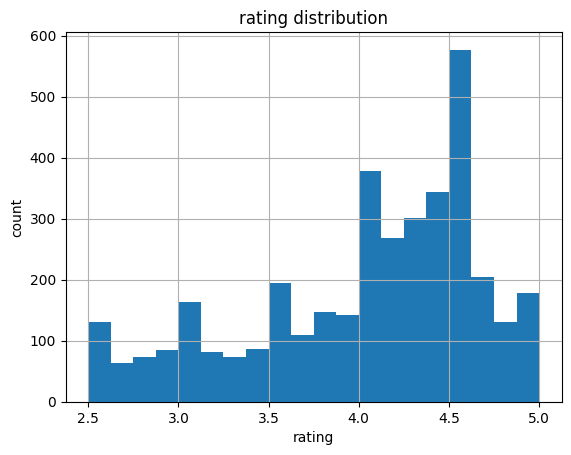

In [ ]:
df['rating'].hist(bins=20)   # how rating are spread
plt.title("rating distribution")
plt.xlabel("rating")
plt.ylabel("count")
plt.show()

In [ ]:
df.groupby('online_delivery')['rating'].mean()  #online delivery Vs rating

,rating
online_delivery,
No,4.02585
Yes,4.02153


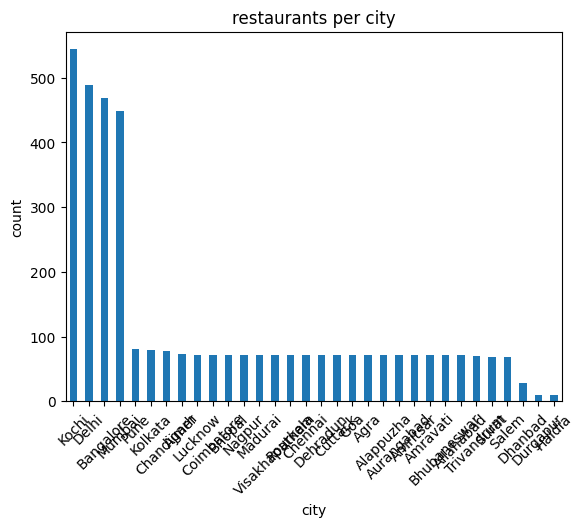

In [ ]:
df['city'].value_counts().plot(kind='bar')    #city distribution
plt.title("restaurants per city")
plt.xlabel("city")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()

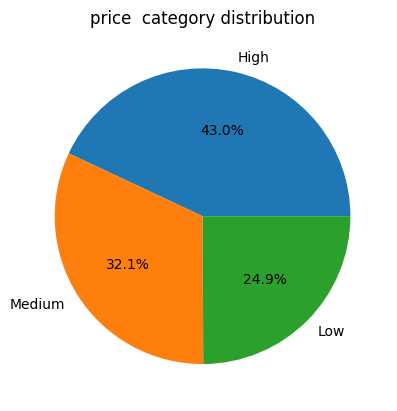

In [ ]:
df['price'].value_counts().plot(kind='pie',autopct = "%1.1f%%" )   #price distribution
plt.title("price  category distribution")
plt.ylabel("")
plt.show()

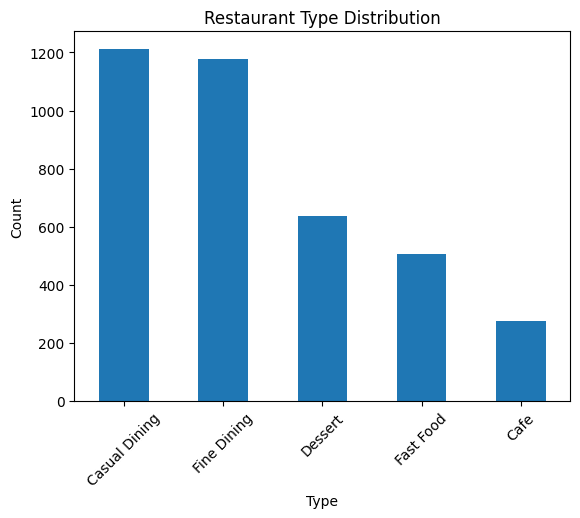

In [ ]:
df['restaurant_type'].value_counts().plot(kind='bar')
plt.title("Restaurant Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

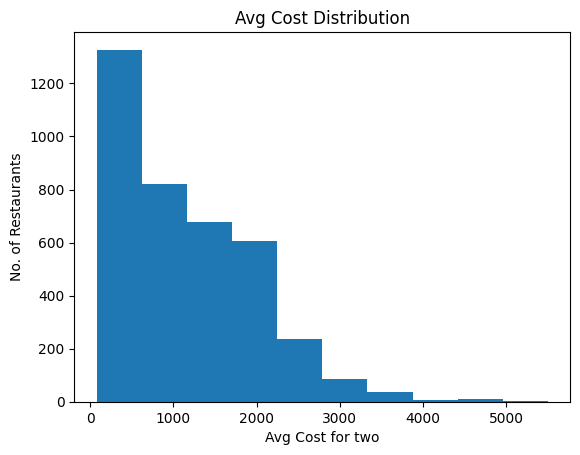

In [ ]:
plt.hist(df['avg_cost_for_two'])
plt.title("Avg Cost Distribution")
plt.ylabel("No. of Restaurants")
plt.xlabel("Avg Cost for two")
plt.show()

In [ ]:
#bivarient  analysis

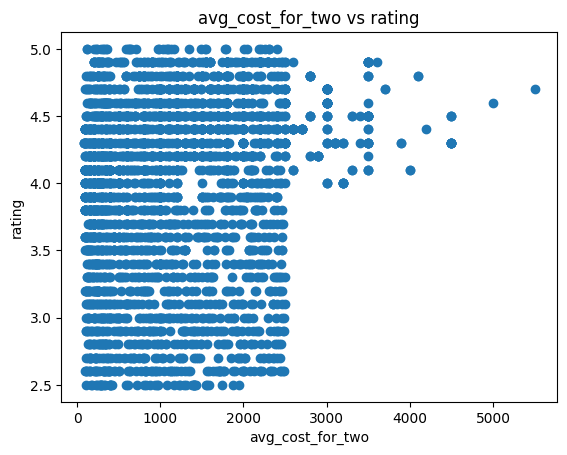

In [ ]:
plt.scatter(df['avg_cost_for_two'], df['rating'])
plt.title("avg_cost_for_two vs rating")    #relationship
plt.xlabel("avg_cost_for_two")
plt.ylabel("rating")
plt.show()

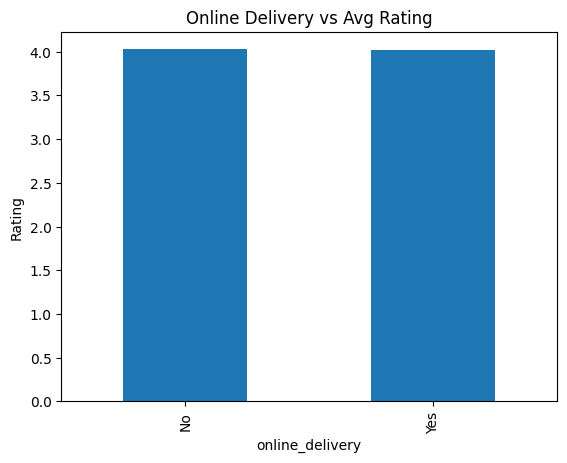

In [ ]:
df.groupby('online_delivery')['rating'].mean().plot(kind='bar')
plt.title("Online Delivery vs Avg Rating")
plt.ylabel("Rating")
plt.show()

In [ ]:
df.groupby('table_booking')['rating'].mean()

,rating
table_booking,
No,4.023961
Yes,4.022722


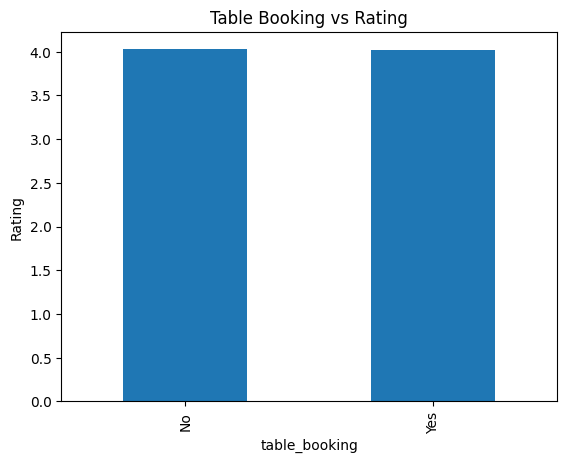

In [ ]:
df.groupby('table_booking')['rating'].mean().plot(kind='bar')
plt.title("Table Booking vs Rating")
plt.ylabel("Rating")
plt.show()

In [ ]:
df.groupby('price')['rating'].mean()

,rating
price,
High,4.142919
Low,3.867338
Medium,3.985351


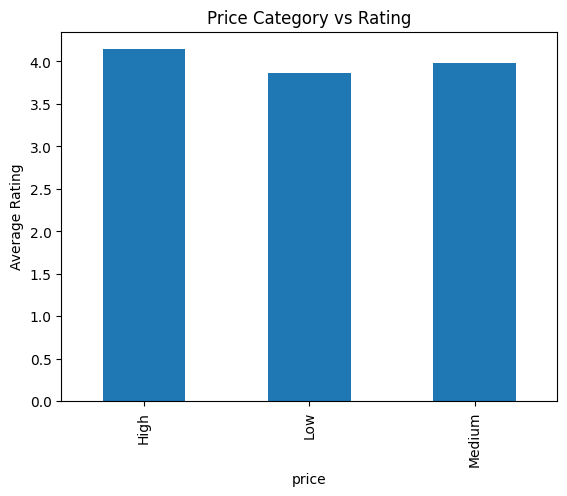

In [ ]:
df.groupby('price')['rating'].mean().plot(kind='bar')
plt.title("Price Category vs Rating")
plt.ylabel("Average Rating")
plt.show()

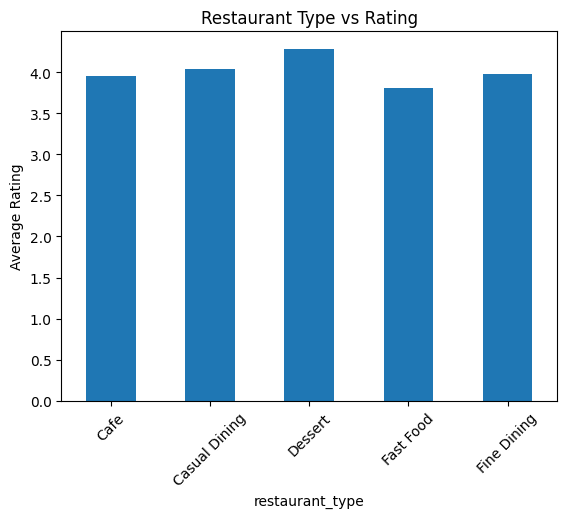

In [ ]:
df.groupby('restaurant_type')['rating'].mean().plot(kind='bar')
plt.title("Restaurant Type vs Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

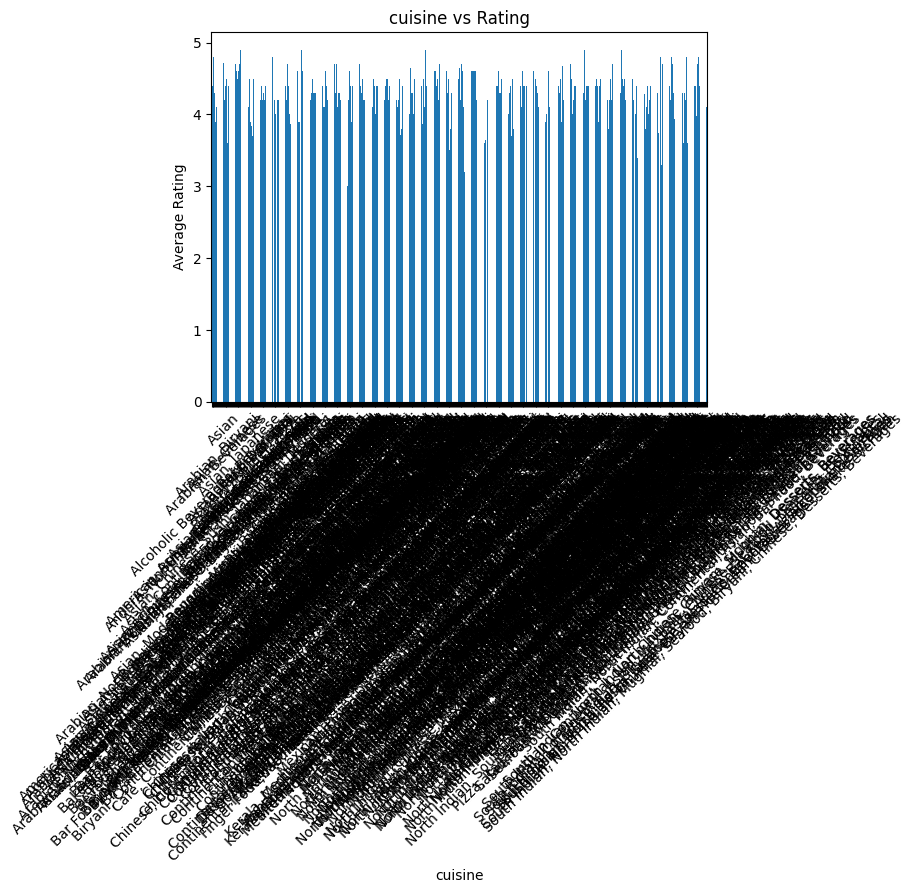

In [ ]:
df.groupby('cuisine')['rating'].mean().plot(kind='bar')
plt.title("cuisine vs Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

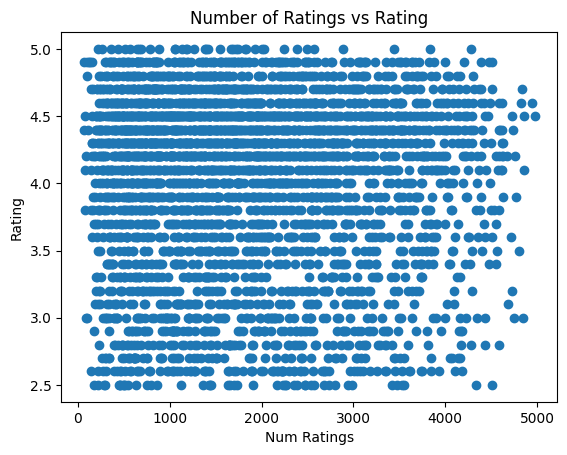

In [ ]:
plt.scatter(df['num_ratings'], df['rating'])
plt.title("Number of Ratings vs Rating")
plt.xlabel("Num Ratings")
plt.ylabel("Rating")
plt.show()

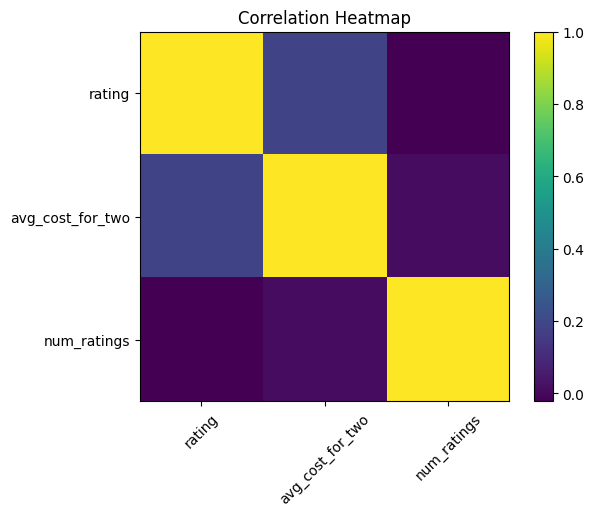

In [ ]:
corr = df[['rating', 'avg_cost_for_two', 'num_ratings']].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3809 entries, 0 to 6598
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  3809 non-null   object 
 1   url                   3809 non-null   object 
 2   rating                3735 non-null   float64
 3   location              3809 non-null   object 
 4   city                  3809 non-null   object 
 5   area                  3809 non-null   object 
 6   cuisine               3395 non-null   object 
 7   price                 3808 non-null   object 
 8   reviews               3809 non-null   int64  
 9   restaurant_type       3809 non-null   object 
 10  num_ratings           3809 non-null   int64  
 11  online_delivery       3809 non-null   object 
 12  table_booking         3809 non-null   object 
 13  avg_cost_for_two      3808 non-null   float64
 14  is_delivering_now     3809 non-null   object 
 15  switch_to_order_menu  3809

In [ ]:
df.describe()

,rating,reviews,num_ratings,avg_cost_for_two
count,3735.000000,3809.000000,3809.000000,3808.000000
mean,4.023400,1792.354686,1848.199002,1147.137868
std,0.635736,1346.786677,1115.603280,828.034125
min,2.500000,11.000000,65.000000,80.000000
25%,3.600000,677.000000,908.000000,400.000000
50%,4.200000,1428.000000,1667.000000,1000.000000
75%,4.500000,2709.000000,2625.000000,1763.000000
max,5.000000,5000.000000,4972.000000,5500.000000


In [ ]:
df.groupby("restaurant_type")["rating"].mean()

,rating
restaurant_type,
Cafe,3.952536
Casual Dining,4.037436
Dessert,4.280671
Fast Food,3.807984
Fine Dining,3.980379


In [ ]:
df.groupby("city")["name"].count()

,name
city,
Agra,72
Ajmer,73
Alappuzha,72
Allahabad,71
Amravati,72
Amritsar,72
Aurangabad,72
Bangalore,469
Bhopal,72


In [ ]:
df.head()

,name,url,rating,location,city,area,cuisine,price,reviews,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,is_delivering_now,switch_to_order_menu
0,85°C Bakery Cafe,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Cafe,Low,1609,Cafe,1992,Yes,No,349.0,No,Yes
1,Applebee's,https://en.wikipedia.org/wiki/List_of_restaura...,4.7,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,1424,Casual Dining,2702,No,No,566.0,No,No
2,Arby's,https://en.wikipedia.org/wiki/List_of_restaura...,4.2,"Kakkanad, Kochi",Kochi,Kakkanad,Restaurant,High,3384,Fine Dining,3690,No,No,1352.0,No,No
3,Auntie Anne's,https://en.wikipedia.org/wiki/List_of_restaura...,3.0,"Navi Mumbai, Mumbai",Mumbai,Navi Mumbai,Restaurant,Medium,1731,Casual Dining,3521,Yes,Yes,1106.0,No,Yes
4,Barista,https://en.wikipedia.org/wiki/List_of_restaura...,4.6,"Saket, Delhi",Delhi,Saket,Restaurant,Medium,3900,Casual Dining,4612,Yes,No,947.0,Yes,Yes


✔ city

✔ rating

✔ cuisine

✔ price

✔ restaurant_type

✔ num_ratings

✔ online_delivery

✔ table_booking

✔ avg_cost_for_two



name  [only fo model]

url   [no pattern, just link]

area   [location taken]

location    [city taken]

reviews  [num_ratings taken]

switch_to_order_menu [same as online delivery, duplicate info.]

is_delivering_now [real-time status]

In [ ]:
df.shape

(3809, 16)

####cleaning

In [ ]:
df = df.drop(columns=[ "url", "area", "location", "reviews", "switch_to_order_menu","is_delivering_now"])

In [ ]:
df.head()

,name,rating,city,cuisine,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two
0,85°C Bakery Cafe,4.6,Delhi,Cafe,Low,Cafe,1992,Yes,No,349.0
1,Applebee's,4.7,Delhi,Restaurant,Medium,Casual Dining,2702,No,No,566.0
2,Arby's,4.2,Kochi,Restaurant,High,Fine Dining,3690,No,No,1352.0
3,Auntie Anne's,3.0,Mumbai,Restaurant,Medium,Casual Dining,3521,Yes,Yes,1106.0
4,Barista,4.6,Delhi,Restaurant,Medium,Casual Dining,4612,Yes,No,947.0


####Handle missing values

In [ ]:
df.isna().sum()

,0
name,0
rating,74
city,0
cuisine,414
price,1
restaurant_type,0
num_ratings,0
online_delivery,0
table_booking,0
avg_cost_for_two,1


In [ ]:
df[df['rating'].isnull()]

,name,rating,city,cuisine,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two
2469,Thakorji Thaal,NaN,Pune,"North Indian, Beverages",Medium,Casual Dining,725,Yes,Yes,900.0
2506,Thakorji Thaal,NaN,Pune,"North Indian, Beverages",Medium,Casual Dining,2365,Yes,No,900.0
2523,Thakorji Thaal,NaN,Pune,"North Indian, Beverages",Medium,Casual Dining,3773,No,No,900.0
2811,Chacoco,NaN,Lucknow,NaN,High,Casual Dining,2714,Yes,Yes,1600.0
2884,Chacoco,NaN,Lucknow,NaN,High,Casual Dining,1395,No,No,1600.0
...,...,...,...,...,...,...,...,...,...,...
6469,Slow Tide,NaN,Goa,Continental,High,Fine Dining,3825,No,Yes,3000.0
6484,Uma by the Sea,NaN,Goa,"North Indian, Biryani, Chinese, Italian, Conti...",High,Dessert,1100,Yes,No,2700.0
6559,Slow Tide,NaN,Goa,Continental,High,Fine Dining,691,No,Yes,3000.0
6575,Uma by the Sea,NaN,Goa,"North Indian, Biryani, Chinese, Italian, Conti...",High,Dessert,2895,Yes,No,2700.0


In [ ]:
df[df['rating'].isnull()][['rating','avg_cost_for_two']]

,rating,avg_cost_for_two
2469,NaN,900.0
2506,NaN,900.0
2523,NaN,900.0
2811,NaN,1600.0
2884,NaN,1600.0
...,...,...
6469,NaN,3000.0
6484,NaN,2700.0
6559,NaN,3000.0
6575,NaN,2700.0


In [ ]:
df[df['rating'].isnull()][['rating','restaurant_type']]

,rating,restaurant_type
2469,NaN,Casual Dining
2506,NaN,Casual Dining
2523,NaN,Casual Dining
2811,NaN,Casual Dining
2884,NaN,Casual Dining
...,...,...
6469,NaN,Fine Dining
6484,NaN,Dessert
6559,NaN,Fine Dining
6575,NaN,Dessert


In [ ]:
df[df['rating'].isnull()][['rating','cuisine']]

,rating,cuisine
2469,NaN,"North Indian, Beverages"
2506,NaN,"North Indian, Beverages"
2523,NaN,"North Indian, Beverages"
2811,NaN,NaN
2884,NaN,NaN
...,...,...
6469,NaN,Continental
6484,NaN,"North Indian, Biryani, Chinese, Italian, Conti..."
6559,NaN,Continental
6575,NaN,"North Indian, Biryani, Chinese, Italian, Conti..."


In [ ]:
df[df['rating'].isnull()].groupby('restaurant_type').size()

,0
restaurant_type,
Casual Dining,42
Dessert,10
Fast Food,6
Fine Dining,16


In [ ]:
#fill missing value for rating:

# Fill based on pattern
df['rating'] = df.groupby(['restaurant_type', 'city'])['rating'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill remaining (if any)
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [ ]:
df.isnull().sum()

,0
name,0
rating,0
city,0
cuisine,414
price,1
restaurant_type,0
num_ratings,0
online_delivery,0
table_booking,0
avg_cost_for_two,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3809 entries, 0 to 6598
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3809 non-null   object 
 1   rating            3809 non-null   float64
 2   city              3809 non-null   object 
 3   cuisine           3395 non-null   object 
 4   price             3808 non-null   object 
 5   restaurant_type   3809 non-null   object 
 6   num_ratings       3809 non-null   int64  
 7   online_delivery   3809 non-null   object 
 8   table_booking     3809 non-null   object 
 9   avg_cost_for_two  3808 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 327.3+ KB


In [ ]:
df[df['cuisine'].isnull()]

,name,rating,city,cuisine,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two
2382,The Bistrograph,4.5,Chennai,NaN,High,Casual Dining,2180,No,Yes,1300.0
2484,Felice Pasticceria,4.3,Pune,NaN,High,Casual Dining,693,Yes,Yes,1400.0
2539,Felice Pasticceria,4.3,Pune,NaN,High,Casual Dining,1012,No,No,1400.0
2542,Ba Ba Reeba,4.4,Pune,NaN,High,Casual Dining,1644,Yes,No,3000.0
2595,Ba Ba Reeba,4.4,Pune,NaN,High,Casual Dining,1279,Yes,No,3000.0
...,...,...,...,...,...,...,...,...,...,...
6436,Koi,4.5,Dehradun,NaN,High,Casual Dining,534,No,No,1600.0
6453,Cafe Delhi Heights,4.6,Dehradun,NaN,High,Casual Dining,687,Yes,Yes,1800.0
6489,Bastian Riviera,3.7,Goa,NaN,NaN,Casual Dining,2910,Yes,Yes,NaN
6526,Si Nonna's - The Original Sourdough Pizza,4.5,Goa,NaN,High,Casual Dining,2539,Yes,Yes,1500.0


In [ ]:
#fill missing value for cuisine

def fill_cuisine(name):
    name = str(name).lower()
    if "pizza" in name:
        return "Italian"
    elif "burger" in name:
        return "Fast Food"
    elif "cafe" in name or "coffee" in name:
        return "Cafe"
    elif "biryani" in name:
        return "Indian"
    elif "chicken" in name:
        return "Fast Food"
    elif "ice cream" in name:
        return "Dessert"
    else:
        return None

df['cuisine'] = df.apply(
    lambda row: fill_cuisine(row['name']) if pd.isnull(row['cuisine']) else row['cuisine'],
    axis=1
)

In [ ]:
df['cuisine'] = df.groupby('restaurant_type')['cuisine'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else None)
)

In [ ]:
df.isnull().sum()

,0
name,0
rating,0
city,0
cuisine,0
price,1
restaurant_type,0
num_ratings,0
online_delivery,0
table_booking,0
avg_cost_for_two,1


In [ ]:
df[df['price'].isnull()]

,name,rating,city,cuisine,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two
6489,Bastian Riviera,3.7,Goa,Restaurant,NaN,Casual Dining,2910,Yes,Yes,NaN


In [ ]:
df['avg_cost_for_two'] = df.groupby('restaurant_type')['avg_cost_for_two']\
                          .transform(lambda x: x.fillna(x.median()))

In [ ]:
def price_category(x):
    if x < 400:
        return "Low"
    elif x < 1200:
        return "Medium"
    else:
        return "High"

df['price'] = df['avg_cost_for_two'].apply(price_category)



In [ ]:
df.isnull().sum()

,0
name,0
rating,0
city,0
cuisine,0
price,0
restaurant_type,0
num_ratings,0
online_delivery,0
table_booking,0
avg_cost_for_two,0


####encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3809 entries, 0 to 6598
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3809 non-null   object 
 1   rating            3809 non-null   float64
 2   city              3809 non-null   object 
 3   cuisine           3809 non-null   object 
 4   price             3809 non-null   object 
 5   restaurant_type   3809 non-null   object 
 6   num_ratings       3809 non-null   int64  
 7   online_delivery   3809 non-null   object 
 8   table_booking     3809 non-null   object 
 9   avg_cost_for_two  3809 non-null   float64
dtypes: float64(2), int64(1), object(7)
memory usage: 327.3+ KB


In [ ]:
df.isnull().sum()

,0
name,0
rating,0
city,0
cuisine,0
price,0
restaurant_type,0
num_ratings,0
online_delivery,0
table_booking,0
avg_cost_for_two,0


####Encode categorical

In [ ]:
#for cuisine

from sklearn.feature_extraction.text import TfidfVectorizer
#first convert list to string
df['cuisine'] = df['cuisine'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

In [ ]:
tfidf = TfidfVectorizer(max_features=50 , stop_words='english')

cuisine_vec = tfidf.fit_transform(df['cuisine'])

cuisine_df = pd.DataFrame(cuisine_vec.toarray(), columns=tfidf.get_feature_names_out(),index=df.index)

df = pd.concat([df, cuisine_df], axis=1)

df.drop('cuisine', axis=1, inplace=True)

In [ ]:
df.head()

,name,rating,city,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,...,rolls,salad,sandwich,seafood,shake,sichuan,south,street,sushi,thai
0,85°C Bakery Cafe,4.6,Delhi,Low,Cafe,1992,Yes,No,349.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Applebee's,4.7,Delhi,Medium,Casual Dining,2702,No,No,566.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Arby's,4.2,Kochi,High,Fine Dining,3690,No,No,1352.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Auntie Anne's,3.0,Mumbai,Medium,Casual Dining,3521,Yes,Yes,1106.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Barista,4.6,Delhi,Medium,Casual Dining,4612,Yes,No,947.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder( categories=[['Low','Medium','High']])
df['price_encoded'] = oe.fit_transform(df[['price']])
#df.drop('price', axis=1, inplace=True)
df.head()


,name,rating,city,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,...,salad,sandwich,seafood,shake,sichuan,south,street,sushi,thai,price_encoded
0,85°C Bakery Cafe,4.6,Delhi,Low,Cafe,1992,Yes,No,349.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Applebee's,4.7,Delhi,Medium,Casual Dining,2702,No,No,566.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Arby's,4.2,Kochi,High,Fine Dining,3690,No,No,1352.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,Auntie Anne's,3.0,Mumbai,Medium,Casual Dining,3521,Yes,Yes,1106.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Barista,4.6,Delhi,Medium,Casual Dining,4612,Yes,No,947.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
df.columns

Index(['name', 'rating', 'city', 'price', 'restaurant_type', 'num_ratings',
       'online_delivery', 'table_booking', 'avg_cost_for_two', 'american',
       'arabian', 'asian', 'bakery', 'bar', 'bbq', 'beverages', 'biryani',
       'burger', 'cafe', 'chinese', 'continental', 'dessert', 'desserts',
       'eastern', 'european', 'fast', 'finger', 'food', 'goan', 'healthy',
       'ice', 'indian', 'italian', 'japanese', 'kebab', 'kerala', 'mandi',
       'mediterranean', 'mexican', 'middle', 'mithai', 'modern', 'momos',
       'mughlai', 'north', 'oriental', 'pasta', 'pizza', 'restaurant', 'rolls',
       'salad', 'sandwich', 'seafood', 'shake', 'sichuan', 'south', 'street',
       'sushi', 'thai', 'price_encoded'],
      dtype='object')

In [ ]:
#location_tires

In [ ]:
df['city'].value_counts()

,count
city,
Kochi,544
Delhi,489
Bangalore,469
Mumbai,449
Pune,81
Kolkata,80
Chandigarh,77
Ajmer,73
Lucknow,72


In [ ]:
tier_1 = [
    "Delhi", "Bangalore", "Mumbai", "Chennai",
    "Kolkata", "Hyderabad", "Pune"
]

In [ ]:
tier_2 = [
    "Kochi", "Chandigarh", "Lucknow", "Coimbatore",
    "Bhopal", "Nagpur", "Surat", "Visakhapatnam",
    "Trivandrum", "Bhubaneswar", "Amritsar"
]

In [ ]:
tier_3 = [
    "Ajmer", "Madurai", "Rourkela", "Dehradun",
    "Cuttack", "Goa", "Agra", "Alappuzha",
    "Aurangabad", "Amravati", "Allahabad",
    "Salem", "Dhanbad", "Durgapur", "Haldia"
]

In [ ]:
def get_tier(city):
    if city in tier_1:
        return "Tier 1"
    elif city in tier_2:
        return "Tier 2"
    else:
        return "Tier 3"

In [ ]:
df['location_tier'] = df['city'].apply(get_tier)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[[ "Tier 3","Tier 2", "Tier 1"]])
df['location_tier'] = oe.fit_transform(df[['location_tier']])

In [ ]:
df.head()

,name,rating,city,price,restaurant_type,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,...,sandwich,seafood,shake,sichuan,south,street,sushi,thai,price_encoded,location_tier
0,85°C Bakery Cafe,4.6,Delhi,Low,Cafe,1992,Yes,No,349.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
1,Applebee's,4.7,Delhi,Medium,Casual Dining,2702,No,No,566.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
2,Arby's,4.2,Kochi,High,Fine Dining,3690,No,No,1352.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
3,Auntie Anne's,3.0,Mumbai,Medium,Casual Dining,3521,Yes,Yes,1106.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
4,Barista,4.6,Delhi,Medium,Casual Dining,4612,Yes,No,947.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0


In [ ]:
df['location_tier'].value_counts()

,count
location_tier,
2.0,1640
1.0,1263
0.0,906


In [ ]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Initialize encoder
ohe = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform
encoded = ohe.fit_transform(df[['restaurant_type']])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['restaurant_type']),
    index=df.index
)

# Concatenate with original dataframe
df = pd.concat([df, encoded_df], axis=1)

# Drop original column
df.drop('restaurant_type', axis=1, inplace=True)

In [ ]:
df.head()

,name,rating,city,price,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
0,85°C Bakery Cafe,4.6,Delhi,Low,1992,Yes,No,349.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,Applebee's,4.7,Delhi,Medium,2702,No,No,566.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
2,Arby's,4.2,Kochi,High,3690,No,No,1352.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
3,Auntie Anne's,3.0,Mumbai,Medium,3521,Yes,Yes,1106.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
4,Barista,4.6,Delhi,Medium,4612,Yes,No,947.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0


In [ ]:
df['online_delivery'] = df['online_delivery'].map({'Yes': 1, 'No': 0})
df['table_booking'] = df['table_booking'].map({'Yes': 1, 'No': 0})

In [ ]:
df['online_delivery'].value_counts()

,count
online_delivery,
1,2155
0,1654


In [ ]:
df['table_booking'].value_counts()

,count
table_booking,
0,2078
1,1731


In [ ]:
df.head()

,name,rating,city,price,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
0,85°C Bakery Cafe,4.6,Delhi,Low,1992,1,0,349.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,Applebee's,4.7,Delhi,Medium,2702,0,0,566.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
2,Arby's,4.2,Kochi,High,3690,0,0,1352.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
3,Auntie Anne's,3.0,Mumbai,Medium,3521,1,1,1106.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
4,Barista,4.6,Delhi,Medium,4612,1,0,947.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0


####scaling

(array([1327.,  823.,  677.,  605.,  236.,   85.,   37.,    7.,   10.,
           2.]),
 array([  80.,  622., 1164., 1706., 2248., 2790., 3332., 3874., 4416.,
        4958., 5500.]),
 <BarContainer object of 10 artists>)

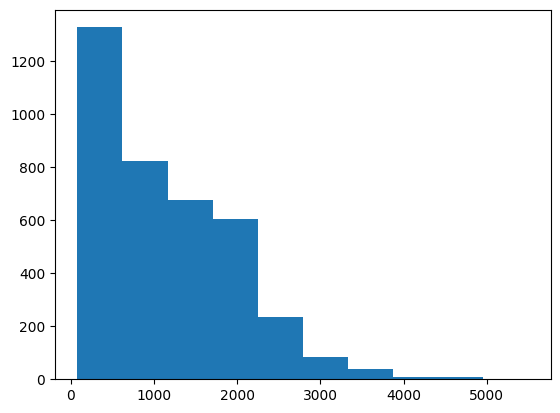

In [ ]:
plt.hist(df['avg_cost_for_two'])

In [ ]:
import numpy as np
#df['avg_cost_for_two']= np.log1p(df['avg_cost_for_two'])

In [ ]:
df.head()

,name,rating,city,price,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
0,85°C Bakery Cafe,4.6,Delhi,Low,1992,1,0,349.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,Applebee's,4.7,Delhi,Medium,2702,0,0,566.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
2,Arby's,4.2,Kochi,High,3690,0,0,1352.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
3,Auntie Anne's,3.0,Mumbai,Medium,3521,1,1,1106.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
4,Barista,4.6,Delhi,Medium,4612,1,0,947.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0


<Axes: >

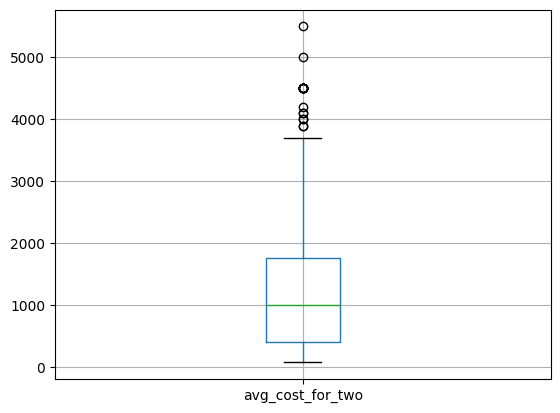

In [ ]:
df.boxplot(column=['avg_cost_for_two'])

In [ ]:
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#df['num_ratings'] = scaler.fit_transform(df[['num_ratings']])

In [ ]:
df.head()

,name,rating,city,price,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
0,85°C Bakery Cafe,4.6,Delhi,Low,1992,1,0,349.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,Applebee's,4.7,Delhi,Medium,2702,0,0,566.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
2,Arby's,4.2,Kochi,High,3690,0,0,1352.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
3,Auntie Anne's,3.0,Mumbai,Medium,3521,1,1,1106.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
4,Barista,4.6,Delhi,Medium,4612,1,0,947.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0


In [ ]:
df = df.drop(columns=[ "name", "city", "price"])

In [ ]:
df.head()

,rating,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,asian,bakery,bar,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
0,4.6,1992,1,0,349.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
1,4.7,2702,0,0,566.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
2,4.2,3690,0,0,1352.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0
3,3.0,3521,1,1,1106.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
4,4.6,4612,1,0,947.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0


In [ ]:
df.describe()

,rating,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,asian,bakery,bar,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
count,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,...,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000,3809.000000
mean,4.026659,1848.199002,0.565765,0.454450,1147.016277,0.004564,0.008586,0.036133,0.007726,0.012986,...,0.027145,0.010503,0.008483,0.012650,1.181938,1.192701,0.318194,0.166973,0.133106,0.309268
std,0.630930,1115.603280,0.495721,0.497986,827.959403,0.047596,0.067886,0.123508,0.065753,0.082983,...,0.105188,0.071209,0.064429,0.078363,0.803896,0.794638,0.465836,0.373001,0.339734,0.462252
min,2.500000,65.000000,0.000000,0.000000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.600000,908.000000,0.000000,0.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,4.200000,1667.000000,1.000000,0.000000,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,4.500000,2625.000000,1.000000,1.000000,1763.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,0.000000,0.000000,1.000000
max,5.000000,4972.000000,1.000000,1.000000,5500.000000,0.663178,0.865035,1.000000,0.879900,0.754048,...,0.850695,0.858882,0.746372,0.866617,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df['success'] = df['rating'].apply(lambda x: 1 if x >= 4.0 else 0)

In [ ]:
df.drop('rating', axis=1, inplace=True)

In [ ]:
df.head()

,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,asian,bakery,bar,bbq,...,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining,success
0,1992,1,0,349.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1
1,2702,0,0,566.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,1
2,3690,0,0,1352.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,1.0,1
3,3521,1,1,1106.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0
4,4612,1,0,947.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,1


In [ ]:
df.to_csv("zomato_cleaned_dataset.csv", index=False)

In [ ]:
x = df.drop(columns=['success'])
y = df['success']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


#Model before scale

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf1 = RandomForestClassifier(random_state=42)
rf1.fit(x_train, y_train)

y_pred1_rf1 = rf1.predict(x_test)
yprob_a_rf1 = rf1.predict_proba(x_test)[:,1]
roc_auc_rf1 = roc_auc_score(y_test,yprob_a_rf1)

print("rf 1 - No scaling, No log")
print("Accuracy:", accuracy_score(y_test, y_pred1_rf1))
print("F1:", f1_score(y_test, y_pred1_rf1))
print("Precision:", precision_score(y_test, y_pred1_rf1))
print("Recall:", recall_score(y_test, y_pred1_rf1))
print('roc_aoc', roc_auc_rf1)

rf 1 - No scaling, No log
Accuracy: 0.7204724409448819
F1: 0.7736450584484591
Precision: 0.7794432548179872
Recall: 0.7679324894514767
roc_aoc 0.8007208157524611


In [ ]:
#decision tree
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier()
dt1.fit(x_train, y_train)

y_pred1_dt1 = dt1.predict(x_test)
yprob_a_dt1 = dt1.predict_proba(x_test)[:,1]
roc_auc_dt1 = roc_auc_score(y_test,yprob_a_dt1)

print("dt 1 - No scaling, No log")
print("Accuracy:", accuracy_score(y_test, y_pred1_dt1))
print("F1:", f1_score(y_test, y_pred1_dt1))
print("Precision:", precision_score(y_test, y_pred1_dt1))
print("Recall:", recall_score(y_test, y_pred1_dt1))
print('roc_aoc', roc_auc_dt1)

dt 1 - No scaling, No log
Accuracy: 0.6837270341207349
F1: 0.7460484720758693
Precision: 0.7452631578947368
Recall: 0.7468354430379747
roc_aoc 0.6633482770745429


In [ ]:
#gradientboost
from sklearn.ensemble import GradientBoostingClassifier
gb1 = GradientBoostingClassifier()
gb1.fit(x_train, y_train)

y_pred1_gb1 = gb1.predict(x_test)
yprob_a_gb1 = gb1.predict_proba(x_test)[:,1]
roc_auc_gb1 = roc_auc_score(y_test,yprob_a_gb1)

print("gb 1 - No scaling, No log")
print("Accuracy:", accuracy_score(y_test, y_pred1_gb1))
print("F1:", f1_score(y_test, y_pred1_gb1))
print("Precision:", precision_score(y_test, y_pred1_gb1))
print("Recall:", recall_score(y_test, y_pred1_gb1))
print('roc_aoc', roc_auc_gb1)

gb 1 - No scaling, No log
Accuracy: 0.7152230971128609
F1: 0.7618002195389681
Precision: 0.7940503432494279
Recall: 0.7320675105485233
roc_aoc 0.7823890939990623


In [ ]:
#LogisticRegression

from sklearn.linear_model import LogisticRegression
lr1 = LogisticRegression()
lr1.fit(x_train, y_train)

y_pred1_lr1 = lr1.predict(x_test)
yprob_a_lr1 = lr1.predict_proba(x_test)[:,1]
roc_auc_lr1 = roc_auc_score(y_test,yprob_a_lr1)

print("lr 1 - No scaling, No log")
print("Accuracy:", accuracy_score(y_test, y_pred1_lr1))
print("F1:", f1_score(y_test, y_pred1_lr1))
print("Precision:", precision_score(y_test, y_pred1_lr1))
print("Recall:", recall_score(y_test, y_pred1_lr1))
print('roc_aoc', roc_auc_lr1)

lr 1 - No scaling, No log
Accuracy: 0.6771653543307087
F1: 0.7442827442827443
Precision: 0.7336065573770492
Recall: 0.7552742616033755
roc_aoc 0.7478976207219877


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#xgbclassifier
from xgboost import XGBClassifier
xg1= XGBClassifier()
xg1.fit(x_train, y_train)

y_pred1_xg1 = xg1.predict(x_test)
yprob_a_xg1 = xg1.predict_proba(x_test)[:,1]
roc_auc_xg1 = roc_auc_score(y_test,yprob_a_xg1)

print("xg 1 - No scaling, No log")
print("Accuracy:", accuracy_score(y_test, y_pred1_xg1))
print("F1:", f1_score(y_test, y_pred1_xg1))
print("Precision:", precision_score(y_test, y_pred1_xg1))
print("Recall:", recall_score(y_test, y_pred1_xg1))
print('roc_aoc', roc_auc_xg1)

xg 1 - No scaling, No log
Accuracy: 0.7165354330708661
F1: 0.7682403433476395
Precision: 0.7816593886462883
Recall: 0.7552742616033755
roc_aoc 0.7962230426629162


In [ ]:
#extratreeclasifier
from sklearn.ensemble import ExtraTreesClassifier
ext1 = ExtraTreesClassifier()
ext1.fit(x_train, y_train)

y_pred1_ext1 = ext1.predict(x_test)
yprob_a_ext1 = ext1.predict_proba(x_test)[:,1]
roc_auc_ext1 = roc_auc_score(y_test,yprob_a_ext1)

print("ext 1 - No scaling, No log")
print("Accuracy:", accuracy_score(y_test, y_pred1_ext1))
print("F1:", f1_score(y_test, y_pred1_ext1))
print("Precision:", precision_score(y_test, y_pred1_ext1))
print("Recall:", recall_score(y_test, y_pred1_ext1))
print('roc_aoc', roc_auc_ext1)

ext 1 - No scaling, No log
Accuracy: 0.7139107611548556
F1: 0.7660944206008584
Precision: 0.7794759825327511
Recall: 0.7531645569620253
roc_aoc 0.7945235583684951


In [ ]:
x_train_mod = x_train.copy()
x_test_mod = x_test.copy()

In [ ]:
#Log transform

import numpy as np

x_train_mod['avg_cost_for_two'] = np.log1p(x_train_mod['avg_cost_for_two'])
x_test_mod['avg_cost_for_two'] = np.log1p(x_test_mod['avg_cost_for_two'])

In [ ]:
#Scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_mod[['num_ratings']] = scaler.fit_transform(x_train_mod[['num_ratings']])
x_test_mod[['num_ratings']] = scaler.transform(x_test_mod[['num_ratings']])

In [ ]:
#Original data → X_train, X_test  [not scaled,not log]
#Modified data → X_train_mod, X_test_mod [scaled,log]

In [ ]:
x_train_mod

,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,asian,bakery,bar,bbq,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
6271,-0.817821,1,0,6.685861,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4516,2.070328,1,0,8.006701,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0
1739,0.254997,1,1,7.709757,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0
5398,0.872407,0,0,7.601402,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0
257,1.188313,1,1,6.313548,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512,-1.029325,0,0,7.778630,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0
1681,-1.313730,0,1,7.440734,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0
1030,-1.146327,1,1,6.552508,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
5577,-1.199428,0,0,5.993961,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [ ]:
x_train

,num_ratings,online_delivery,table_booking,avg_cost_for_two,american,arabian,asian,bakery,bar,bbq,...,south,street,sushi,thai,price_encoded,location_tier,restaurant_type_Casual Dining,restaurant_type_Dessert,restaurant_type_Fast Food,restaurant_type_Fine Dining
6271,938,1,0,800.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4516,4147,1,0,3000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0
1739,2130,1,1,2229.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0
5398,2816,0,0,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0
257,3167,1,1,551.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512,703,0,0,2388.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0
1681,387,0,1,1703.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,1.0
1030,573,1,1,700.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0
5577,514,0,0,400.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


#Model after scale

In [ ]:
#GradientBoostingClassifier

from sklearn.ensemble import GradientBoostingClassifier
#from sklearn.metrics import mean_squared_error, r2_score
gb = GradientBoostingClassifier()
gb.fit(x_train_mod, y_train)

GradientBoostingClassifier()

In [ ]:
y_pred_gb = gb.predict(x_test_mod)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
yprob_a_gb = gb.predict_proba(x_test_mod)[:,1]
roc_auc_gb = roc_auc_score(y_test,yprob_a_gb)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_gb)

Accuracy: 0.7125984251968503
Precision: 0.7931034482758621
Recall: 0.7278481012658228
F1 Score: 0.759075907590759
ROC-AUC: 0.7814953996718237


In [ ]:
#RandomForestClassifier

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train_mod, y_train)

RandomForestClassifier()

In [ ]:
y_pred_rf = rf.predict(x_test_mod)

In [ ]:
yprob_a_rf = rf.predict_proba(x_test_mod)[:,1]
roc_auc_rf = roc_auc_score(y_test,yprob_a_rf)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_rf)

Accuracy: 0.7099737532808399
Precision: 0.7792494481236203
Recall: 0.7447257383966245
F1 Score: 0.761596548004315
ROC-AUC: 0.8005486697140178


In [ ]:
#DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_mod, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_dt = dt.predict(x_test_mod)


In [ ]:
yprob_a_dt = dt.predict_proba(x_test_mod)[:,1]
roc_auc_dt = roc_auc_score(y_test,yprob_a_dt)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_dt)

Accuracy: 0.6916010498687664
Precision: 0.7547974413646056
Recall: 0.7468354430379747
F1 Score: 0.750795334040297
ROC-AUC: 0.6737649437412094


In [ ]:
#LogisticRegression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train_mod, y_train)

LogisticRegression()

In [ ]:
y_pred_lr = lr.predict(x_test_mod)

In [ ]:
yprob_a_lr = lr.predict_proba(x_test_mod)[:,1]
roc_auc_lr = roc_auc_score(y_test,yprob_a_lr)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_lr)


Accuracy: 0.6811023622047244
Precision: 0.7595505617977528
Recall: 0.7130801687763713
F1 Score: 0.735582154515778
ROC-AUC: 0.7526884083450539


In [ ]:
#XGBClassifier
from xgboost import XGBClassifier
xg = XGBClassifier()
xg.fit(x_train_mod, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = xg.predict(x_test_mod)

In [ ]:
yprob_a_xg = lr.predict_proba(x_test_mod)[:,1]
roc_auc_xg = roc_auc_score(y_test,yprob_a_xg)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xg))
print("Precision:", precision_score(y_test, y_pred_xg))
print("Recall:", recall_score(y_test, y_pred_xg))
print("F1 Score:", f1_score(y_test, y_pred_xg))
print("ROC-AUC:", roc_auc_xg)


Accuracy: 0.7165354330708661
Precision: 0.7816593886462883
Recall: 0.7552742616033755
F1 Score: 0.7682403433476395
ROC-AUC: 0.7526884083450539


In [ ]:
#SVC
from sklearn.svm import SVC
svm = SVC(probability = True)
svm.fit(x_train_mod, y_train)

SVC(probability=True)

In [ ]:
y_pred_svm = svm.predict(x_test_mod)
yprob_a_svm = svm.predict_proba(x_test_mod)[:,1]
roc_auc_svm = roc_auc_score(y_test,yprob_a_svm)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_svm)


Accuracy: 0.6981627296587927
Precision: 0.7863849765258216
Recall: 0.7067510548523207
F1 Score: 0.7444444444444445
ROC-AUC: 0.7376933895921238


In [ ]:
#KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_mod, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(x_test_mod)
yprob_a_knn = knn.predict_proba(x_test_mod)[:,1]
roc_auc_knn = roc_auc_score(y_test,yprob_a_knn)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_knn)


Accuracy: 0.6981627296587927
Precision: 0.7863849765258216
Recall: 0.7067510548523207
F1 Score: 0.7444444444444445
ROC-AUC: 0.735733854899203


In [ ]:
#GaussianNB
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train_mod, y_train)

GaussianNB()

In [ ]:
y_pred_nb = nb.predict(x_test_mod)
yprob_a_nb = nb.predict_proba(x_test_mod)[:,1]
roc_auc_nb = roc_auc_score(y_test,yprob_a_nb)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1 Score:", f1_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_nb)


Accuracy: 0.6220472440944882
Precision: 0.9227272727272727
Recall: 0.4282700421940928
F1 Score: 0.5850144092219021
ROC-AUC: 0.7326169127988749


In [ ]:
#AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier()
ada.fit(x_train_mod, y_train)

AdaBoostClassifier()

In [ ]:
y_pred_ada = ada.predict(x_test_mod)
yprob_a_ada = ada.predict_proba(x_test_mod)[:,1]
roc_auc_ada = roc_auc_score(y_test,yprob_a_ada)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall:", recall_score(y_test, y_pred_ada))
print("F1 Score:", f1_score(y_test, y_pred_ada))
print("ROC-AUC:", roc_auc_ada)


Accuracy: 0.6601049868766404
Precision: 0.716297786720322
Recall: 0.7510548523206751
F1 Score: 0.733264675592173
ROC-AUC: 0.7292509083450539


In [ ]:
#BaggingClassifier
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier()
bag.fit(x_train_mod, y_train)

BaggingClassifier()

In [ ]:
y_pred_bag = bag.predict(x_test_mod)
yprob_a_bag = bag.predict_proba(x_test_mod)[:,1]
roc_auc_bag = roc_auc_score(y_test,yprob_a_bag)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print("Precision:", precision_score(y_test, y_pred_bag))
print("Recall:", recall_score(y_test, y_pred_bag))
print("F1 Score:", f1_score(y_test, y_pred_bag))
print("ROC-AUC:", roc_auc_bag)


Accuracy: 0.7112860892388452
Precision: 0.7981220657276995
Recall: 0.7172995780590717
F1 Score: 0.7555555555555555
ROC-AUC: 0.7802647386310361


In [ ]:
#ExtraTreesClassifier
from sklearn.ensemble import ExtraTreesClassifier
ext = ExtraTreesClassifier()
ext.fit(x_train_mod, y_train)

ExtraTreesClassifier()

In [ ]:
y_pred_ext = ext.predict(x_test_mod)
yprob_a_ext = ext.predict_proba(x_test_mod)[:,1]
roc_auc_ext = roc_auc_score(y_test,yprob_a_ext)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_ext))
print("Precision:", precision_score(y_test, y_pred_ext))
print("Recall:", recall_score(y_test, y_pred_ext))
print("F1 Score:", f1_score(y_test, y_pred_ext))
print("ROC-AUC:", roc_auc_ext)


Accuracy: 0.6955380577427821
Precision: 0.7607758620689655
Recall: 0.7447257383966245
F1 Score: 0.7526652452025586
ROC-AUC: 0.7893665025785279


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# function to evaluate model
def evaluate_model(model, X_test_mod, y_test):
    y_pred = model.predict(X_test_mod)
    y_prob = model.predict_proba(X_test_mod)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# dictionary to store results
results = {}

# models (you already trained these)
models = {
    "Logistic Regression": lr,
    "GradientBoostingClassifier": gb,
    "RandomForestClassifier": rf,
    "DecisionTreeClassifier": dt,
    "XGBClassifier": xg,
    "SVC": svm,
    "KNeighborsClassifier": knn,
    "GaussianNB": nb,
    "AdaBoostClassifier": ada,
    "BaggingClassifier": bag,
    "ExtraTreesClassifier": ext
}
# loop through models
for name, model in models.items():
    results[name] = evaluate_model(model, x_test_mod, y_test)

# convert to dataframe
results_df = pd.DataFrame(results).T

# display
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.681102,0.759551,0.713080,0.735582,0.752688
GradientBoostingClassifier,0.712598,0.793103,0.727848,0.759076,0.781495
RandomForestClassifier,0.709974,0.779249,0.744726,0.761597,0.800549
DecisionTreeClassifier,0.691601,0.754797,0.746835,0.750795,0.673765
XGBClassifier,0.716535,0.781659,0.755274,0.768240,0.796223
SVC,0.698163,0.786385,0.706751,0.744444,0.737693
KNeighborsClassifier,0.671916,0.742424,0.723629,0.732906,0.735734
GaussianNB,0.622047,0.922727,0.428270,0.585014,0.732617
AdaBoostClassifier,0.660105,0.716298,0.751055,0.733265,0.729251
BaggingClassifier,0.711286,0.798122,0.717300,0.755556,0.780265


In [ ]:
results_df.sort_values(by='ROC-AUC', ascending=False,inplace=True)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
RandomForestClassifier,0.709974,0.779249,0.744726,0.761597,0.800549
XGBClassifier,0.716535,0.781659,0.755274,0.768240,0.796223
ExtraTreesClassifier,0.695538,0.760776,0.744726,0.752665,0.789367
GradientBoostingClassifier,0.712598,0.793103,0.727848,0.759076,0.781495
BaggingClassifier,0.711286,0.798122,0.717300,0.755556,0.780265
Logistic Regression,0.681102,0.759551,0.713080,0.735582,0.752688
SVC,0.698163,0.786385,0.706751,0.744444,0.737693
KNeighborsClassifier,0.671916,0.742424,0.723629,0.732906,0.735734
GaussianNB,0.622047,0.922727,0.428270,0.585014,0.732617
AdaBoostClassifier,0.660105,0.716298,0.751055,0.733265,0.729251


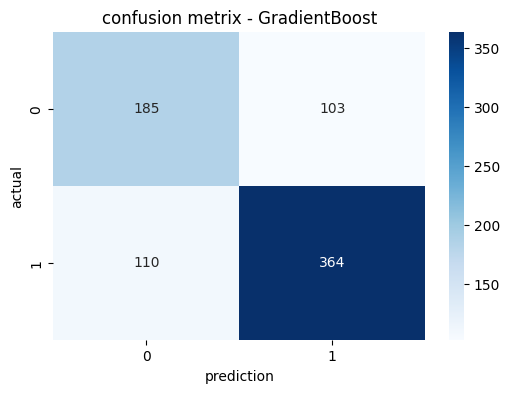

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred1_rf1)
plt.figure(figsize= (6,4))
sns.heatmap(cm, annot = True,fmt='d',cmap='Blues')  #formats the displayed numbers as integers
plt.title('confusion metrix - GradientBoost')
plt.xlabel('prediction')
plt.ylabel('actual')
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(rf1,x,y,cv=5,scoring='accuracy')

#Train and test the gb model 5 different times and store the accuracy scores.
print('cross validation score : ',cv_score)
print('Mean cv accuracy :', cv_score.mean())

cross validation score :  [0.39632546 0.53018373 0.79002625 0.57217848 0.6412615 ]
Mean cv accuracy : 0.5859950817580128


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# function to evaluate model
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

# dictionary to store results
results = {}

# models (you already trained these)
models = {
    "Logistic Regression": lr1,
    "GradientBoostingClassifier": gb1,
    "RandomForestClassifier": rf1,
    "DecisionTreeClassifier": dt1,
    "XGBClassifier": xg1,
#"SVC": svm1,
  #  "KNeighborsClassifier": knn,
  #  "GaussianNB": nb,
  #  "AdaBoostClassifier": ada,
   # "BaggingClassifier": bag,
    "ExtraTreesClassifier": ext1
}
# loop through models
for name, model in models.items():
    results[name] = evaluate_model(model, x_test, y_test)

# convert to dataframe
results_df_1 = pd.DataFrame(results).T
print('model before scale')
# display
results_df_1

model before scale


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.677165,0.733607,0.755274,0.744283,0.747898
GradientBoostingClassifier,0.715223,0.794050,0.732068,0.761800,0.782389
RandomForestClassifier,0.720472,0.779443,0.767932,0.773645,0.800721
DecisionTreeClassifier,0.683727,0.745263,0.746835,0.746048,0.663348
XGBClassifier,0.716535,0.781659,0.755274,0.768240,0.796223
ExtraTreesClassifier,0.713911,0.779476,0.753165,0.766094,0.794524


In [ ]:
results_df_1.sort_values(by='ROC-AUC', ascending=False,inplace=True)
results_df_1

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
RandomForestClassifier,0.720472,0.779443,0.767932,0.773645,0.800721
XGBClassifier,0.716535,0.781659,0.755274,0.768240,0.796223
ExtraTreesClassifier,0.713911,0.779476,0.753165,0.766094,0.794524
GradientBoostingClassifier,0.715223,0.794050,0.732068,0.761800,0.782389
Logistic Regression,0.677165,0.733607,0.755274,0.744283,0.747898
DecisionTreeClassifier,0.683727,0.745263,0.746835,0.746048,0.663348


# Comparison of Random Forest performance before and after scaling:
## Before Scaling  -> Accuracy: 0.72, ROC-AUC: 0.80
## After Scaling   -> Accuracy: 0.71, ROC-AUC: 0.79
#
# Observation:
## The model performed slightly better without scaling.
## This is expected because Random Forest is a tree-based model,
# which is not sensitive to feature scaling.
#
# Conclusion:
## Random Forest without scaling is chosen as the final model.

In [154]:
from sklearn.model_selection import GridSearchCV
# parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# grid search
grid = GridSearchCV(
    estimator=rf1,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# train
grid.fit(x_train, y_train)

# best params
print("Best Params:", grid.best_params_)

# best model
best_rf = grid.best_estimator_

Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [156]:
y_pred = best_rf.predict(x_test)
y_prob = best_rf.predict_proba(x_test)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7283464566929134
ROC-AUC: 0.7976075363338022


In [158]:
result_rf = pd.DataFrame({
    'model':['Random Forest ','tuned Random Forest'],
    'accuracy':[accuracy_score(y_test, y_pred1_rf1), accuracy_score(y_test, y_pred)],

    'ROC-AUC':[roc_auc_rf1,roc_auc_score(y_test, y_prob)]

})
result_rf

,model,accuracy,ROC-AUC
0,Random Forest,0.720472,0.800721
1,tuned Random Forest,0.728346,0.797608



### Hyperparameter tuning was performed on the Random Forest model.
### Although tuning slightly improved accuracy, the ROC-AUC score decreased.
#
### Since ROC-AUC is the primary evaluation metric for this project,
### the untuned model was selected as it provides better overall performance.



##Feature Importance Analysis

In [160]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
features = x.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_imp.head(10))

             Feature  Importance
3   avg_cost_for_two    0.101550
39             north    0.091178
55     location_tier    0.088422
26            indian    0.083399
0        num_ratings    0.065785
43        restaurant    0.056854
17          desserts    0.047001
15       continental    0.045051
10         beverages    0.038364
14           chinese    0.035866


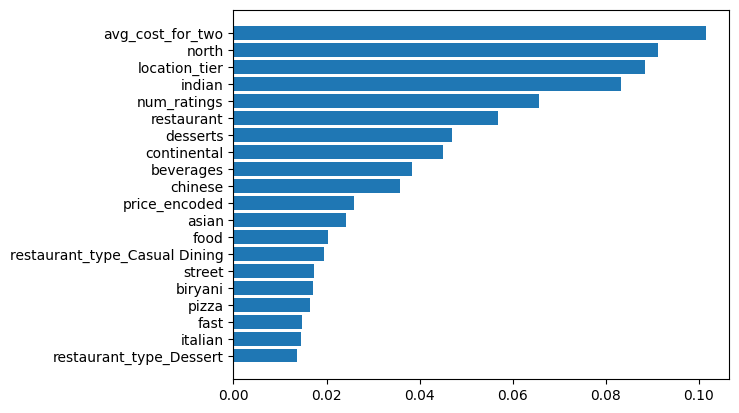

In [162]:
top_n = 20
top_features = feat_imp.head(top_n)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.show()

###model saving

In [159]:
import pickle   # for saving it

with open('tuned_random_forest_zomato.pkl','wb') as f:
  pickle.dump(rf1,f)